# Solução numérica para o problema homogeneizado

In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Propriedades do material

In [25]:
class Composite:
    # ---------------------------
    # Exemplo de coeficientes (variáveis) e suas derivadas
    # ajuste conforme seu modelo microestrutural
    # ---------------------------
    def __init__(self, L=3.0, y_I=0.8, eps=0.1, n_layers=2, mesh_size=100, y_domain=None):
        self.L = L # comprimento do período
        self.n_layers = n_layers  # número de camadas
        self.y_I = y_I # posição da interface
        self.eps = eps # Parâmetro geométrico pequeno
        self.mesh_size = mesh_size
        self.y_domain = y_domain if y_domain is not None else np.linspace(0, self.L, self.mesh_size)
        self.layer_bounds = [0.0, y_I, L]  # 40% camada 1, 60% camada 2
        self.layer_values = [
            (2.0, 1.0),   # camada 1
            (5.0, 2.0)    # camada 2
        ]

    def C11(self, y):
        y_mod = y % self.L  # garante periodicidade
        for (a,b), (c11, c12) in zip(zip(self.layer_bounds[:-1], self.layer_bounds[1:]), self.layer_values):
            if a <= y_mod < b or np.isclose(y_mod, b):
                return c11

    def C12(self, y):
        y_mod = y % self.L
        for (a,b), (c11, c12) in zip(zip(self.layer_bounds[:-1], self.layer_bounds[1:]), self.layer_values):
            if a <= y_mod < b or np.isclose(y_mod, b):
                return c12
            
    def C11_var(self, y):
        return np.array([self.C11(yi) for yi in y])
    
    def C12_var(self, y):
        return np.array([self.C12(yi) for yi in y])
            
    def calc_eff_coefficients(self, y, N11_corr, N12_corr):
        # C11 efetivo é a média ponderada de C11 nas camadas
        C11_hat = np.trapz(self.C11_var(y) + N11_corr*y, y)
        C12_hat = np.trapz(self.C12_var(y) + N12_corr*y, y)
        return C11_hat, C12_hat

## Solução do problema local

Está com problemas

In [ ]:
from scipy.integrate import solve_bvp

# --- Definição do sistema geral ---
class Local_problem:
    '''
    Descrição: Recebe os parâmetros do compósito (composite) e calcula as funções locais (N11 e N12),
    com base nas condições de contorno.
        composite -> instância da classe Composite, contendo os parâmetros do compósito (espessura, coeficientes elásticos)
        bcs -> [g_a, g_b] : Condições de contorno de Neumann
    '''
    def __init__(self, composite, bcs):
        self._C11 = composite.C11
        self._C12 = composite.C12
        self.L = composite.L
        self.bcs = bcs

    # Sistema de equações
    def ode_system(self, y, U, f):
        # U[0] = u, U[1] = u'
        du = U[1]
        ddu = (0.0 - f(y) - self._C11(y)*U[1]) / self._C11(y)  # mas lembrando que o balanço = 0 => derivada da quantidade é zero
        return np.vstack((du, ddu))

    # wrapper para N11
    def fun_N11(self, y, U):
        # f(y) = C11(y)
        du = U[1]
        ddu = np.zeros_like(y)  # pois d/dy(C11*u' + C11) = 0 => derivada zero
        return np.vstack((du, ddu))

    # wrapper para N12
    def fun_N12(self, y, U):
        # f(y) = C12(y)
        du = U[1]
        ddu = np.zeros_like(y)
        return np.vstack((du, ddu))

    # Condições de contorno: fixamos arbitrário u(0)=0, u'(1)=0 (exemplo)
    # Preciso incluir a condição de periodicidade
    def bc(self, UA, UB):
        # Dirichlet em a e Neumann em b (Tem que ser Neumann em a e b, pois são impostas pressões)
        return np.array([UA[0] - self.bcs[0], UB[1] - self.bcs[1]])
    
    # Solução do problema local
    def solve_local(self, composite):
        # --- Malha inicial ---
        y = composite.y_domain
        U_init = np.zeros((2, y.size))

        fun_N11 = self.fun_N11
        fun_N12 = self.fun_N12
        # bc = self.bc()

        # Resolver para N11
        sol_N11 = solve_bvp(fun = fun_N11, x = y, bc = lambda  UA, UB: self.bc(UA, UB), y = U_init)

        # Resolver para N12
        sol_N12 = solve_bvp(fun = fun_N12, x = y, bc = lambda  UA, UB: self.bc(UA, UB), y = U_init)

        # --- Pós-processamento: ajustar para média nula ---
        def weighted_average(y, u):
            # média ponderada cilíndrica: ∫ u r dr / ∫ r dr
            r = y   # aqui, se y for a coordenada radial
            num = np.trapz(u*r, y)
            den = np.trapz(r, y)
            return num/den

        N11 = sol_N11.sol(y)[0]
        N12 = sol_N12.sol(y)[0]

        avg11 = weighted_average(y, N11)
        avg12 = weighted_average(y, N12)

        N11_corr = N11 - avg11
        N12_corr = N12 - avg12

        return N11_corr, N12_corr


: 

## Cálculo dos coeficientes efetivos

## Solução numérica dos problemas e comparação

In [36]:
class numerical_solution:
    def __init__(self, composite, ri=1.0, re=2.0, p=1.0):
    # ---------------------------
    # Parâmetros do problema
    # ---------------------------
        self.composite = composite
        # self.local_problem = local_problem
        self.ri = ri
        self.re = re
        self.p = p

    
    # ---------------------------
    # Coeficientes efetivos (constantes)
    # ---------------------------
    def compute_effective_coefficients(self, y, N11_corr, N12_corr):
        C11_hat, C12_hat = self.composite.calc_eff_coefficients(y, N11_corr, N12_corr)

        print(r"$\hat{C_{11}}$:", C11_hat)
        print(r"$\hat{C_{12}}$:", C12_hat)
        return C11_hat, C12_hat
    # ---------------------------
    # Sistema ODE: y = [u, u']
    # ---------------------------
    def ode_variable(self, r, y):
        u = y[0]
        du = y[1]

        C11 = self.composite.C11_var(r)
        C11p = np.gradient(C11, r)  # derivada numérica
        C12 = self.composite.C12_var(r)
        C12p = np.gradient(C12, r)  # derivada numérica

        # d(r*C11)/dr = C11 + r*C11'
        drC11 = C11 + r*C11p

        # RHS for y1' from expression anterior (array aware)
        # y1' = -(1/C11) * [ (1/r)*drC11 * y1 + ( (1/r)*C12p - C11/r^2 ) * y0 ]
        term1 = (1.0/r) * drC11 * du
        term2 = (1.0/r) * C12p * u - (C11 / (r**2)) * u
        ddu = - (term1 + term2) / C11

        return np.vstack((du, ddu))

    # ---------------------------
    # Condições de contorno (variáveis)
    # ya = y(ri), yb = y(re)
    # return two residuals: [BC_at_ri, BC_at_re]
    # ---------------------------
    def bc_variable(self, ya, yb):
        ui, dui = ya[0], ya[1]
        ue, due = yb[0], yb[1]

        sigma_i = self.composite.C11(self.ri)*dui + self.composite.C12(self.ri)*ui/self.ri
        sigma_e = self.composite.C11(self.re)*due + self.composite.C12(self.re)*ue/self.re

        return np.array([sigma_i + self.p, sigma_e - 0.0])  # sigma_i = -p -> sigma_i + p = 0

    # ---------------------------
    # Resolução numérica (variável)
    # ---------------------------
    def solve_num(self):
        r_mesh = np.linspace(self.ri, self.re, self.composite.mesh_size)
        # chute inicial: u ~ A*r + B/r with A=B=0 → evita singularidades
        y_init = np.zeros((2, r_mesh.size))

        sol_var = solve_bvp(self.ode_variable, self.bc_variable, r_mesh, y_init, max_nodes=10000)

        print("Convergiu (variável)?", sol_var.success)
        if not sol_var.success:
            print("Mensagem:", sol_var.message)
        return sol_var

    # ---------------------------
    # Solução efetiva (constantes) + solução analítica para validação
    # ---------------------------

    def ode_eff(r, y):
        # y1' = -(1/C11_hat)[ (1/r) d(r C11_hat)/dr * y1 + ( (1/r)*0 - C11_hat/r^2 )*y0 ]
        # d(r*C11_hat)/dr = C11_hat (const) + r*0 = C11_hat
        # Simplifica para: y1' = -(1/C11_hat)[ (1/r)*C11_hat*y1 - (C11_hat/r^2)*y0 ]
        # => y1' = -(1/r)*y1 + (1/r**2)*y0
        u, du = y
        ddu = -(1.0/r)*du + (1.0/r**2)*u
        return np.vstack((du, ddu))

    def bc_eff(self, ya, yb):
        ui, dui = ya[0], ya[1]
        ue, due = yb[0], yb[1]
        C11_hat, C12_hat = self.composite.calc_eff_coefficients(y, self.N11_corr, self.N12_corr)
        sigma_i = C11_hat*dui + C12_hat*ui/self.ri
        sigma_e = C11_hat*due + C12_hat*ue/self.re
        return np.array([sigma_i + self.p, sigma_e - 0.0])

    def solve_eff(self):
        # numérico para efetivo
        y_init_eff = np.zeros((2, self.composite.mesh_size))
        sol_eff = solve_bvp(self.ode_eff, self.bc_eff, self.composite.y_domain, y_init_eff)

        print("Convergiu (efetivo)?", sol_eff.success)
        return sol_eff

    # ---------------------------
    # Solução analítica para o caso efetivo:
    # u(r) = A*r + B/r, determinar A,B pelas BCs (sistema linear)
    # ---------------------------
    def analytical_solution(self):
        sol_eff = self.solve_eff()
        y = self.composite.y_domain
        C11_hat, C12_hat = self.composite.calc_eff_coefficients(y, self.N11_corr, self.N12_corr)
        S1 = C11_hat + C12_hat
        S2 = C12_hat - C11_hat
        # cuidado caso S2 == 0 (degenerescência)
        if abs(S2*(1.0/self.ri**2 - 1.0/self.re**2)) < 1e-14:
            print("Caso degenerado: S2*(1/ri^2 - 1/re^2) aproximadamente zero. Ajuste parâmetros.")
        else:
            B = -self.p / ( S2*(1.0/self.ri**2 - 1.0/self.re**2) )
            A = - (S2*B)/(S1*self.re**2)   # obtido da equação sigma(re)=0
            def u_analytic(r): return A*r + B/r

            # comparar no mesh
            u_eff_num = sol_eff.sol(self.r_mesh)[0]
            u_eff_ana = u_analytic(self.r_mesh)

            err = np.max(np.abs(u_eff_num - u_eff_ana))
            print(f"Erro máximo numérico vs analítico (efetivo): {err:.3e}")
            return u_eff_num, u_eff_ana, S1, S2

    # ---------------------------
    # Plots
    # ---------------------------
    def plot_solutions(self):
        plt.figure(figsize=(8,5))
        sol_var = self.solve_num()
        sol_eff = self.solve_eff()
        u_eff_ana, u_eff_num, S1, S2 = self.analytical_solution()

        if sol_var.success:
            plt.plot(self.composite.mesh_size, sol_var.sol(self.composite.mesh_size)[0], label='u(r) - variável (num.)', lw=2)
        if sol_eff.success:
            plt.plot(self.composite.mesh_size, sol_eff.sol(self.composite.mesh_size)[0], '--', label='u(r) - efetivo (num.)', lw=2)
        if abs(S2*(1.0/self.ri**2 - 1.0/self.re**2)) > 1e-14:
            plt.plot(self.composite.mesh_size, u_eff_ana, ':', label='u(r) - efetivo (analítico)', lw=2)

        plt.xlabel('r'); plt.ylabel('u(r)'); plt.legend(); plt.grid(True)
        plt.show()

# Solução do problema

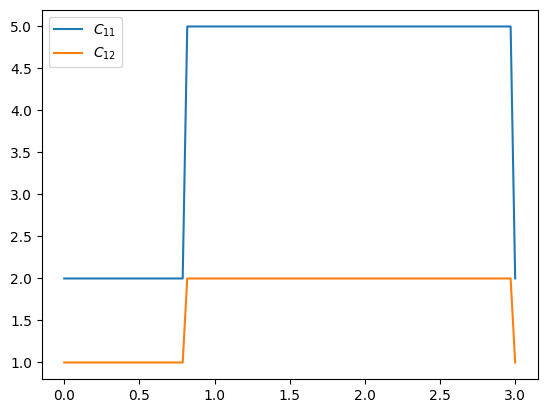

In [27]:
composite = Composite()  # 3 layers, total thickness 0.3 m = 300 mm
y = composite.y_domain

# vetor no mesh
c11 = composite.C11_var(y)
f11 = c11.copy()
c12 = composite.C12_var(y)

plt.plot(y, c11, label=r'$C_{11}$')
plt.plot(y, c12, label=r'$C_{12}$')
plt.legend()

C:\Users\gusta\AppData\Local\Temp\ipykernel_11664\3874103858.py:64: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  num = np.trapz(u*r, y)
C:\Users\gusta\AppData\Local\Temp\ipykernel_11664\3874103858.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  den = np.trapz(r, y)


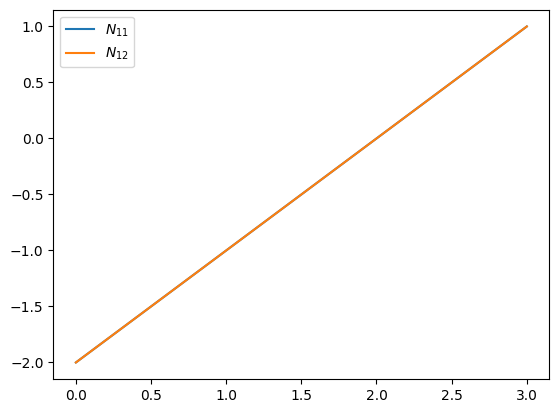

In [28]:
y = composite.y_domain
local_problem = Local_problem(composite=composite, bcs = [0,1])
N11 = local_problem.solve_local(composite)[0]
N12 = local_problem.solve_local(composite)[1]

plt.figure()
plt.plot(y, N11, label=r'$N_{11}$')
plt.plot(y, N12, label=r'$N_{12}$')
plt.legend()

In [37]:
material_params = {
    'L': 3.0,
    'y_I': 0.5,
    'eps':0.1,
    'mesh_size':100
}

problem_params = {
    'composite': Composite(**material_params),
    'ri': 1.0,   # inner radius
    're': 2.0,   # outer radius
    'p': 1e6,    # internal pressure in Pa
    'bcs': [0,1]
}

local_problem = Local_problem(composite=problem_params['composite'], bcs=problem_params['bcs'])
solution = numerical_solution(composite=problem_params['composite'], 
                              ri=problem_params['ri'], 
                              re=problem_params['re'], 
                              p=problem_params['p'])

solution.plot_solutions()

Convergiu (variável)? True


TypeError: numerical_solution.ode_eff() takes 2 positional arguments but 3 were given

<Figure size 800x500 with 0 Axes>

C:\Users\gusta\AppData\Local\Temp\ipykernel_11664\3874103858.py:64: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  num = np.trapz(u*r, y)
C:\Users\gusta\AppData\Local\Temp\ipykernel_11664\3874103858.py:65: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  den = np.trapz(r, y)


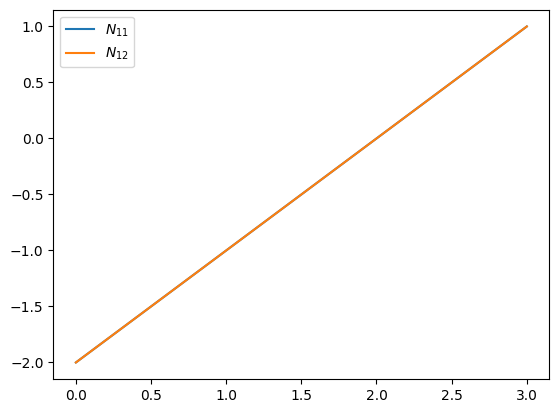

In [29]:
y = composite.y_domain
local_problem = Local_problem(composite=composite, bcs = [0,1])
N11 = local_problem.solve_local(composite)[0]
N12 = local_problem.solve_local(composite)[1]

plt.figure()
plt.plot(y, N11, label=r'$N_{11}$')
plt.plot(y, N12, label=r'$N_{12}$')
plt.legend()